# NaiNUQ demo: 6 h sub-surface emulator forecast skill

This notebook runs the pre-trained **NaiNUQ 6 h emulator** (ocean sub-surface currents used as forcings) on the subset of the 2019 test set available on Zenodo, and reproduces

1. the **forecast RMSE** against NANUQ as a function of lead time (emulator vs. persistence), and
2. a **map of sea-ice thickness** at day 10, emulator vs. NANUQ.

It reuses the repository code (`UNetModel`, `Test.apply_emulator`), so the numbers are computed exactly like in `inference/test.py`.

**Prerequisites** (see the README): conda env `nainuq`, weights downloaded in `weights/`, test data downloaded in `data/`.
Place this notebook in `<repo>/notebooks/`.

> **What "RMSE" means here.** `Test.apply_emulator` computes, for each lead time, the RMSE of the *de-normalised, masked* fields averaged over the full 128×128 grid (land cells are set to 0 in both fields, but still count in the denominator). Same definition as the `*_fs_mean.npy` files used for the paper figures.

In [2]:
import os, sys, io, argparse, contextlib
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
from pathlib import Path
from unittest import mock

import numpy as np
import torch
import tensorflow as tf
try:
    tf.config.set_visible_devices([], "GPU")   # TF is only used to read TFRecords; keep the GPU for PyTorch
except Exception:
    pass
import matplotlib.pyplot as plt
from tqdm.auto import tqdm, trange

# ------------------------------------------------------------------ paths
REPO_ROOT   = Path("..").resolve()        # notebook lives in <repo>/notebooks/
WEIGHTS_DIR = REPO_ROOT / "weights"
DATA_DIR    = REPO_ROOT / "data"
OUT_DIR     = REPO_ROOT / "notebooks" / "demo_output"
OUT_DIR.mkdir(exist_ok=True)

# ------------------------------------------------------------------ emulator configuration
# (6 h, sub-surface ocean as forcings: same as inference/test_nainuq.slurm)
VARIABLES             = ["sit", "sic", "siu", "siv", "snt"]
TIMESTEP              = 6       # hours per emulator step
NN_SIZE               = 32
USE_OCEAN_AS_FORCINGS = True
POST_PROCESSING       = True

# ------------------------------------------------------------------ forecast configuration
K         = 41     # emulator steps per forecast. Step index 40 = 10 days; index 0 is the initial state
FREQUENCY = 12     # hours between two forecast start times
N_CYCLE   = 600     # number of forecasts for the demo (the paper-style statistics use 600)

## 1. Locate code, weights, data and normalisation constants

In [3]:
CODE_DIR = REPO_ROOT / "nainuq"             # contains layers/, inference/, datasets/
assert (CODE_DIR / "layers" / "full_UNet.py").exists(), f"Repo code not found in {CODE_DIR}"
MASK_PATH = CODE_DIR / "layers" / "mask2_nanuk1.npy"

# weights (prefer last.ckpt, as in the slurm script)
ckpts = sorted(WEIGHTS_DIR.rglob("*.ckpt")) + sorted(WEIGHTS_DIR.rglob("*.pt"))
assert ckpts, f"No checkpoint found under {WEIGHTS_DIR}"
CKPT_PATH = ([c for c in ckpts if c.name == "last.ckpt"] or ckpts)[0]

# data: the folder holding the normalisation constants is the "data_path" expected by Test
norm_files = sorted(DATA_DIR.rglob("sea_ice_mean_input.npy"))
assert norm_files, f"sea_ice_mean_input.npy not found under {DATA_DIR}"
DATA_PATH = str(norm_files[0].parent) + "/"
TFRECORDS = sorted(Path(DATA_PATH).rglob("data_20*.tfrecords.*"))
assert TFRECORDS, f"No data_2019.tfrecords.* found under {DATA_PATH}"

print("checkpoint :", CKPT_PATH)
print("data path  :", DATA_PATH)
print("tfrecords  :", len(TFRECORDS), "shard(s)")
print("mask       :", MASK_PATH)

checkpoint : /bettik/PROJECTS/pr-sasip/ducharlo/nainuq/weights/last.ckpt
data path  : /bettik/PROJECTS/pr-sasip/ducharlo/nainuq/data/
tfrecords  : 88 shard(s)
mask       : /bettik/PROJECTS/pr-sasip/ducharlo/nainuq/nainuq/layers/mask2_nanuk1.npy


## 2. Import the repository code

Two small workarounds are needed to call `Test.apply_emulator` from a notebook, handled by `repo_quirks()`:

- `Test.__init__` loads the land mask from an absolute path on the authors' cluster → we redirect it to the mask shipped in the repo.
- `apply_emulator` writes a ~270 MB `x_truth.npy` at every call and prints a lot → we disable `np.save` and silence stdout while it runs.

In [4]:
sys.path.insert(0, str(CODE_DIR))
from layers.full_UNet import UNetModel
from inference.test_utils import Test

@contextlib.contextmanager
def repo_quirks():
    real_load = np.load
    def load(path, *a, **k):
        if str(path).endswith("mask2_nanuk1.npy"):
            path = MASK_PATH
        return real_load(path, *a, **k)
    with mock.patch.object(np, "load", load), \
         mock.patch.object(np, "save", lambda *a, **k: None), \
         contextlib.redirect_stdout(io.StringIO()):
        yield

## 3. Load the model

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

N_OCEAN = 5 if USE_OCEAN_AS_FORCINGS else 0
N_UNDER = 0
IN_CH   = 7 + N_UNDER + N_OCEAN + len(VARIABLES)    # 17 for this configuration
OUT_CH  = len(VARIABLES)

with repo_quirks():
    model = UNetModel(
        data_path=DATA_PATH, in_channels=IN_CH, out_channels=OUT_CH, base_features=NN_SIZE,
        lr=1e-4, weight_decay=1e-3, lambda_bias=0, lambda_PINN=0, lambda_TV=0,
        save_dir=str(OUT_DIR),
    ).to(device)

checkpoint = torch.load(CKPT_PATH, map_location=device, weights_only=True)
model.load_state_dict(checkpoint["state_dict"])
model.eval()
print(f"device: {device} | in_channels={IN_CH}, out_channels={OUT_CH} | "
      f"{sum(p.numel() for p in model.parameters())/1e6:.1f} M parameters")

device: cuda | in_channels=17, out_channels=5 | 1.9 M parameters


## 4. Load the test data

Records are **hourly** (8760 per year); a 6 h emulator step moves 6 records forward. Channels 0–4 are the normalised sea-ice state (sit, sic, siu, siv, snt), the rest are atmospheric and ocean forcings.

`Sea_ice_dataset` re-scans its shard for every sample, which is slow for many records, so we stream the TFRecords once with the same parsing (same `inputs` feature, same NaN → 0 replacement) and only read the hours needed for `N_CYCLE` forecasts.

In [6]:
N_TOT_INPUT     = 17 if USE_OCEAN_AS_FORCINGS else 12
steps_per_cycle = (K - 1) * TIMESTEP + 1                  # hours covered by one forecast
n_needed        = (N_CYCLE - 1) * FREQUENCY + steps_per_cycle

feature_description = {
    "inputs":  tf.io.FixedLenFeature([N_TOT_INPUT * 128 * 128], tf.float32),
    "outputs": tf.io.FixedLenFeature([5 * 128 * 128], tf.float32),
}
ds = tf.data.TFRecordDataset([str(f) for f in TFRECORDS]).take(n_needed)

records = []
for raw in tqdm(ds, total=n_needed, desc="reading TFRecords"):
    parsed = tf.io.parse_single_example(raw, feature_description)
    records.append(parsed["inputs"].numpy().reshape(N_TOT_INPUT, 128, 128))

x_all = torch.nan_to_num(torch.from_numpy(np.stack(records)).float(), 0.0)
del records
print("loaded:", tuple(x_all.shape), "= (hours, channels, y, x)")

# the subset may be shorter than requested: reduce the number of forecasts accordingly
n_max = (x_all.shape[0] - steps_per_cycle) // FREQUENCY + 1
assert n_max >= 1, "Not enough hourly records for one forecast: reduce K."
if N_CYCLE > n_max:
    print(f"Only {x_all.shape[0]} hourly records available -> N_CYCLE reduced from {N_CYCLE} to {n_max}")
    N_CYCLE = n_max

reading TFRecords:   0%|          | 0/7429 [00:00<?, ?it/s]

loaded: (7429, 17, 128, 128) = (hours, channels, y, x)


In [8]:
# Sanity check: input channels match the network, and one forward pass gives the 5 increments
assert x_all.shape[1] == IN_CH, (x_all.shape[1], IN_CH)
with torch.no_grad():
    y = model(x_all[:1].to(device))
print("one-step output:", tuple(y.shape), "(expected (1, 5, 128, 128))")

one-step output: (1, 5, 128, 128) (expected (1, 5, 128, 128))


## 5. Run the forecasts and compute the RMSE

For each start time `i * FREQUENCY`, the emulator is initialised from the NANUQ state, then iterated `K - 1` times (6 h each), fed with the NANUQ forcings. At every step the RMSE against NANUQ is computed, as well as the persistence RMSE (initial state held constant).

In [9]:
args = argparse.Namespace(sea_ice_variables=VARIABLES, k=K)
with repo_quirks():
    tester = Test(
        args, model=model, frequency=FREQUENCY,
        use_ocean_as_forcings=USE_OCEAN_AS_FORCINGS, N_ocean=N_OCEAN,
        post_processing=POST_PROCESSING, N_under=N_UNDER,
        N_inputs=IN_CH, N_outputs=OUT_CH, ocean=False, season="all",
        k=K, N_cycle=N_CYCLE, timestep=TIMESTEP, save_pred=False,
        path_to_save=str(OUT_DIR) + "/", path_to_data=DATA_PATH,
        noise_init=False, noise=0,
    )

fs, fs_pers, bias = [], [], []
pred0 = truth0 = None
for i in trange(N_CYCLE, desc="forecasts"):
    start = i * FREQUENCY
    window = x_all[start : start + steps_per_cycle]
    with repo_quirks():
        rmse, rmse_pers, b, pred, truth = tester.apply_emulator(window)
    fs.append(rmse); fs_pers.append(rmse_pers); bias.append(b)
    if i == 0:
        pred0, truth0 = pred, truth      # (K, 5, 128, 128), physical units, masked

fs, fs_pers, bias = map(np.stack, (fs, fs_pers, bias))     # (N_CYCLE, K, 5): same layout as the paper's *_fs_mean.npy
np.save(OUT_DIR / "demo_fs_mean.npy", fs)
np.save(OUT_DIR / "demo_fs_mean_pers.npy", fs_pers)
print("RMSE array:", fs.shape, "= (forecasts, lead steps, variables)")

forecasts:   0%|          | 0/600 [00:00<?, ?it/s]

RMSE array: (600, 41, 5) = (forecasts, lead steps, variables)


## 6. RMSE summary

`lead_days = step × 6 h / 24`. Values are averaged over the `N_CYCLE` forecasts.

In [10]:
UNITS = {"sit": "m", "sic": "-", "siu": "m/s", "siv": "m/s", "snt": "m"}
lead_days = np.arange(K) * TIMESTEP / 24

# Reference values from the paper (RMSE at 10 days) -> fill in to get a side-by-side comparison
PAPER_RMSE_10D = {"sit": None, "sic": None, "siu": None, "siv": None, "snt": None}

print(f"Mean over {N_CYCLE} forecasts")
print(f"{'var':<5}{'unit':<6}{'lead':>7}{'emulator':>12}{'persistence':>14}{'paper':>10}")
for lead in (1, 5, 10):
    idx = int(round(lead * 24 / TIMESTEP))
    if idx >= K:
        continue
    for j, v in enumerate(VARIABLES):
        ref = PAPER_RMSE_10D[v] if lead == 10 else None
        ref_s = f"{ref:10.4f}" if ref is not None else f"{'':>10}"
        print(f"{v:<5}{UNITS[v]:<6}{lead:>5} d{fs[:, idx, j].mean():>12.4f}{fs_pers[:, idx, j].mean():>14.4f}{ref_s}")
    print()

Mean over 600 forecasts
var  unit     lead    emulator   persistence     paper
sit  m         1 d      0.0150        0.0289          
sic  -         1 d      0.0109        0.0188          
siu  m/s       1 d      0.0204        0.0470          
siv  m/s       1 d      0.0207        0.0479          
snt  m         1 d      0.0014        0.0029          

sit  m         5 d      0.0520        0.0956          
sic  -         5 d      0.0310        0.0593          
siu  m/s       5 d      0.0228        0.0637          
siv  m/s       5 d      0.0233        0.0646          
snt  m         5 d      0.0044        0.0097          

sit  m        10 d      0.0765        0.1485          
sic  -        10 d      0.0429        0.0912          
siu  m/s      10 d      0.0232        0.0646          
siv  m/s      10 d      0.0236        0.0663          
snt  m        10 d      0.0063        0.0154          



## 7. Plot 1: forecast RMSE vs. lead time

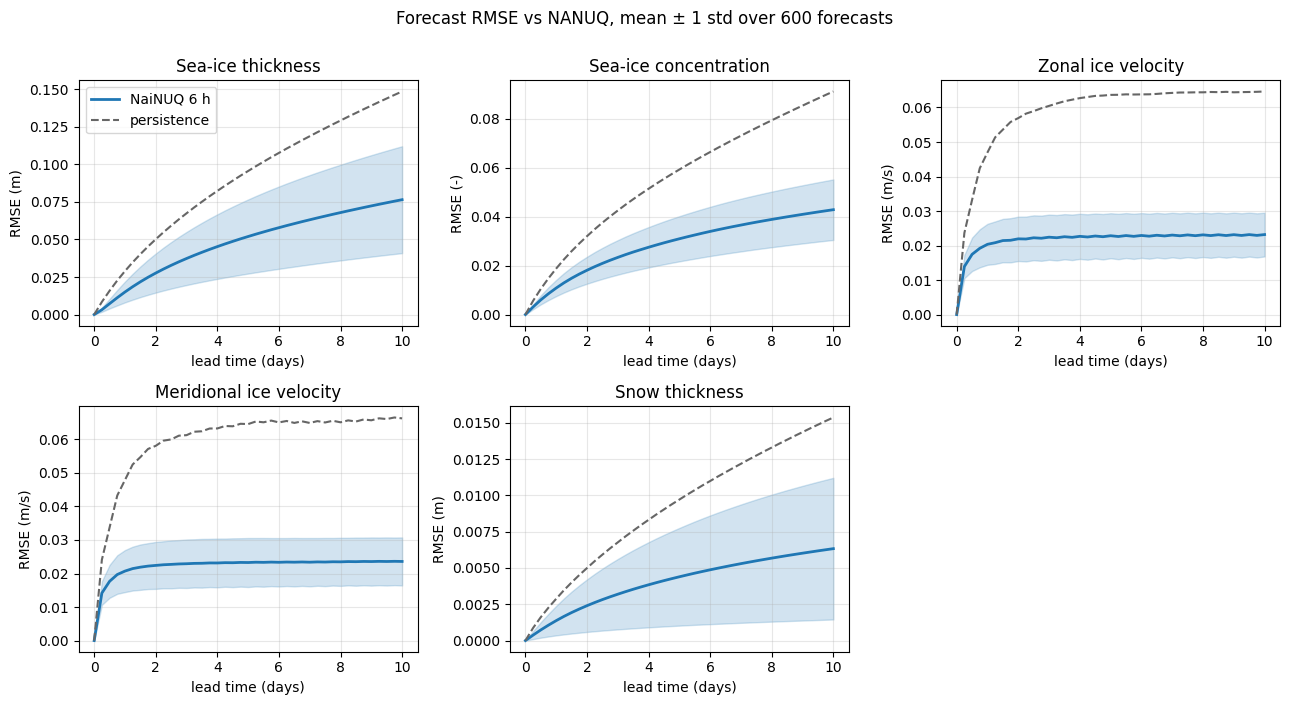

In [11]:
LABELS = {"sit": "Sea-ice thickness", "sic": "Sea-ice concentration", "siu": "Zonal ice velocity",
          "siv": "Meridional ice velocity", "snt": "Snow thickness"}

fig, axes = plt.subplots(2, 3, figsize=(13, 7), sharex=True)
for j, (v, ax) in enumerate(zip(VARIABLES, axes.flat)):
    m, s = fs[:, :, j].mean(0), fs[:, :, j].std(0)
    mp = fs_pers[:, :, j].mean(0)
    ax.plot(lead_days, m, color="C0", lw=2, label="NaiNUQ 6 h")
    ax.fill_between(lead_days, m - s, m + s, color="C0", alpha=0.2)
    ax.plot(lead_days, mp, color="0.4", ls="--", lw=1.5, label="persistence")
    ax.set_title(LABELS[v]); ax.set_ylabel(f"RMSE ({UNITS[v]})"); ax.grid(alpha=0.3)
    ax.tick_params(labelbottom=True); ax.set_xlabel("lead time (days)")
axes.flat[0].legend()
for ax in list(axes.flat)[len(VARIABLES):]:
    ax.axis("off")
fig.suptitle(f"Forecast RMSE vs NANUQ, mean ± 1 std over {N_CYCLE} forecasts", y=1.0)
fig.tight_layout()
fig.savefig(OUT_DIR / "rmse_vs_lead.png", dpi=150)
plt.show()

## 8. Plot 2: sea-ice thickness at day 10, emulator vs. NANUQ

First forecast of the run; land is shown in grey. The array origin is set to the bottom-left; use `origin="upper"` if the map looks flipped for your grid.

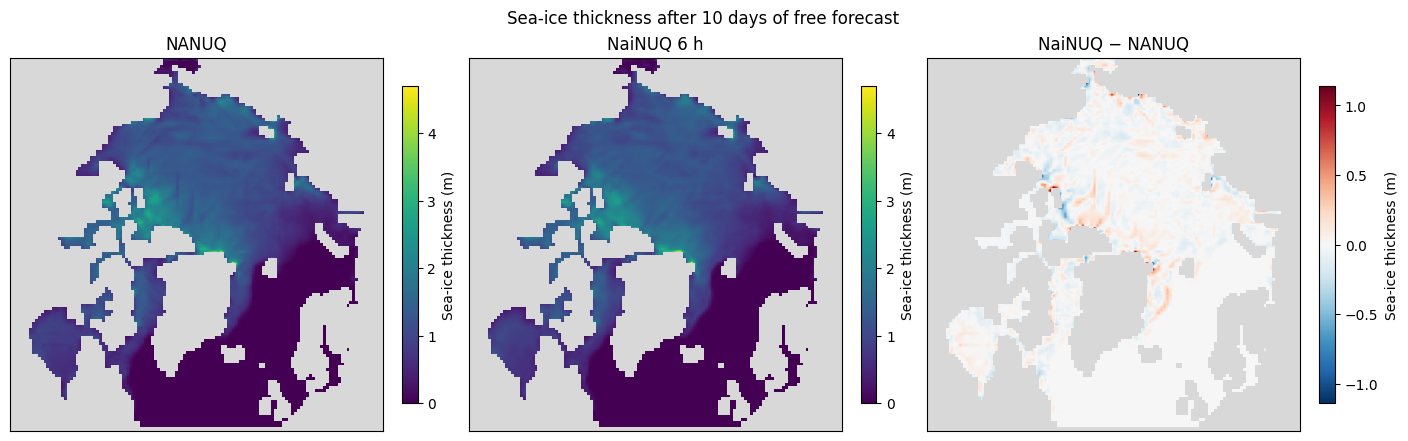

In [12]:
MAP_VAR, MAP_LEAD_DAYS = "sit", 10
j   = VARIABLES.index(MAP_VAR)
idx = min(int(round(MAP_LEAD_DAYS * 24 / TIMESTEP)), K - 1)

land = np.load(MASK_PATH) == 0
def ocean_only(a): return np.where(land, np.nan, a)

truth_f = ocean_only(truth0[idx, j])
pred_f  = ocean_only(pred0[idx, j])
diff_f  = pred_f - truth_f

cmap = plt.get_cmap("viridis").copy(); cmap.set_bad("0.85")
cmap_d = plt.get_cmap("RdBu_r").copy(); cmap_d.set_bad("0.85")
vmax = np.nanmax(truth_f); dmax = np.nanmax(np.abs(diff_f))

fig, axes = plt.subplots(1, 3, figsize=(14, 4.3), constrained_layout=True)
panels = [(truth_f, "NANUQ", cmap, 0, vmax), (pred_f, "NaiNUQ 6 h", cmap, 0, vmax),
          (diff_f, "NaiNUQ − NANUQ", cmap_d, -dmax, dmax)]
for ax, (f, title, cm, lo, hi) in zip(axes, panels):
    im = ax.imshow(f, origin="lower", cmap=cm, vmin=lo, vmax=hi)
    ax.set_title(title); ax.set_xticks([]); ax.set_yticks([])
    fig.colorbar(im, ax=ax, shrink=0.85, label=f"{LABELS[MAP_VAR]} ({UNITS[MAP_VAR]})")
fig.suptitle(f"{LABELS[MAP_VAR]} after {idx * TIMESTEP / 24:.0f} days of free forecast")
fig.savefig(OUT_DIR / "sit_map_day10.png", dpi=150)
plt.show()

## Notes

- **Reproducing the paper statistics.** The paper figures read `test_results/*_cycle_600_fs_mean.npy` and take step index 40 (10 days) for the 6 h model. `fs` above has the same layout `(forecasts, lead steps, variables)`, so set `N_CYCLE = 600` (needs the full year of data, ~10 GB in memory) to compare like with like. With `N_CYCLE = 20` the numbers are indicative only (they depend on which start dates are sampled).
- **Different from `test.py`?** No: this notebook calls the same `Test.apply_emulator`. Only the data loading (single streaming pass) and the cycle loop (no `x_pred_SI` accumulation of all fields) differ, to keep memory and runtime small.
- **Cluster path in `inference/test_utils.py`.** `Test.__init__` loads the mask from `/linkhome/.../mask2_nanuk1.npy`, and `apply_emulator` writes `x_truth.npy` at every call. `repo_quirks()` works around both; a `mask_path` argument and an option to skip this save would make the scripts runnable as-is.